### Dataset Loading, Profiling & Preprocessing Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_covtype
from ydata_profiling import ProfileReport

# 1. Load Forest Cover Type Dataset
covtype = fetch_covtype(as_frame=True)
df = covtype.frame

# Subsample (e.g. 50,000 rows) for faster computation and profiling
df_sampled = df.sample(n=50000, random_state=42)

# 2. Generate profiling report on sampled data
profile = ProfileReport(df_sampled, title="Forest Cover Type Profiling Report", minimal=True)
profile.to_file("forest_cover_profiling.html")
print("Profiling report saved as forest_cover_profiling.html")

C:\Users\victo\AppData\Local\Temp\ipykernel_22488\2807618468.py:6: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 55/55 [00:00<00:00, 80.01it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profiling report saved as forest_cover_profiling.html


### Train / Test Split & Feature Standardization

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and multiclass target (y)
X = df_sampled.drop(columns=["Cover_Type"])
y = df_sampled["Cover_Type"]

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize features (crucial for Logistic Regression and distance-based k-NN)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

### One-vs-All (OvR) Logistic Regression

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Fit Logistic Regression with One-vs-Rest strategy
logreg_ova = LogisticRegression(max_iter=500, solver="lbfgs", random_state=42)
logreg_ova.fit(X_train_std, y_train)

# Predictions & evaluation
y_pred_lr = logreg_ova.predict(X_test_std)

print(f"Logistic Regression (OvR) Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n")
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression (One-vs-All)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

Logistic Regression (OvR) Accuracy: 0.7240

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           1       0.71      0.70      0.71      3680
           2       0.75      0.80      0.77      4860
           3       0.68      0.82      0.74       617
           4       0.67      0.36      0.47        44
           5       0.00      0.00      0.00       159
           6       0.48      0.22      0.30       293
           7       0.72      0.61      0.66       347

    accuracy                           0.72     10000
   macro avg       0.57      0.50      0.52     10000
weighted avg       0.71      0.72      0.71     10000



C:\Users\victo\AppData\Local\Temp\ipykernel_22488\3827624061.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### k-Nearest Neighbors (k-NN)

k-NN (k=5) Accuracy: 0.8322

k-NN Classification Report:
              precision    recall  f1-score   support

           1       0.84      0.83      0.84      3680
           2       0.85      0.87      0.86      4860
           3       0.75      0.81      0.78       617
           4       0.69      0.57      0.62        44
           5       0.70      0.46      0.55       159
           6       0.62      0.52      0.57       293
           7       0.86      0.77      0.81       347

    accuracy                           0.83     10000
   macro avg       0.76      0.69      0.72     10000
weighted avg       0.83      0.83      0.83     10000



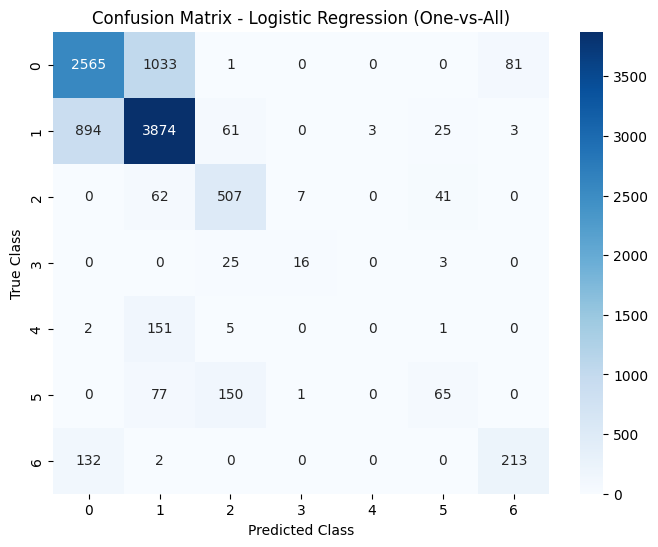

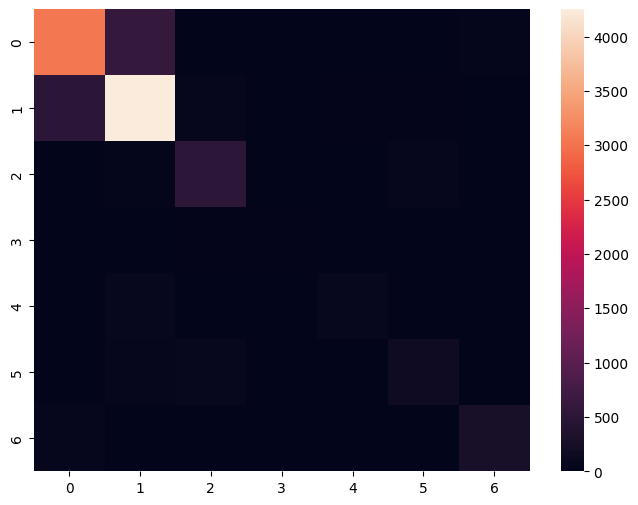

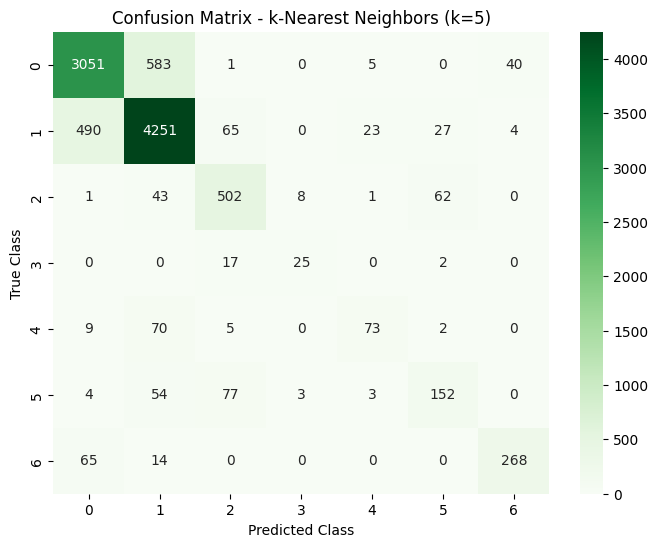

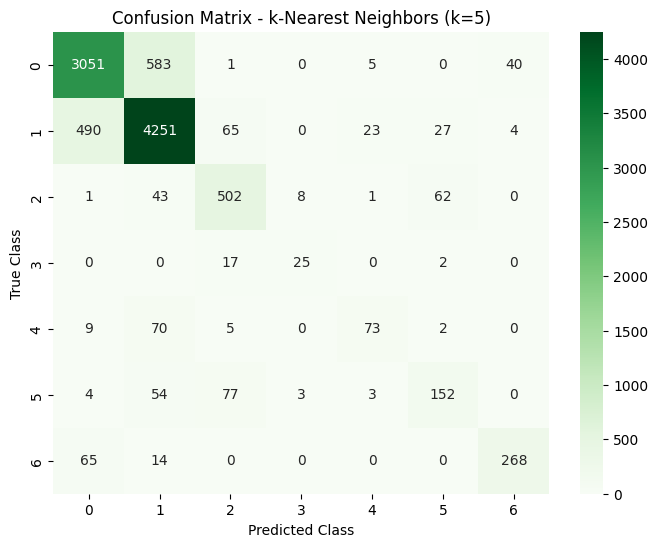

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Fit k-NN model (k=5)
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_std, y_train)

# Predictions & evaluation
y_pred_knn = knn.predict(X_test_std)

print(f"k-NN (k=5) Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}\n")
print("k-NN Classification Report:")
print(classification_report(y_test, y_pred_knn, zero_division=0))

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - k-Nearest Neighbors (k=5)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

### Hyperparameter Tuning (k-NN Values)

k = 3 | Accuracy = 0.8406
k = 5 | Accuracy = 0.8322
k = 7 | Accuracy = 0.8253
k = 9 | Accuracy = 0.8228


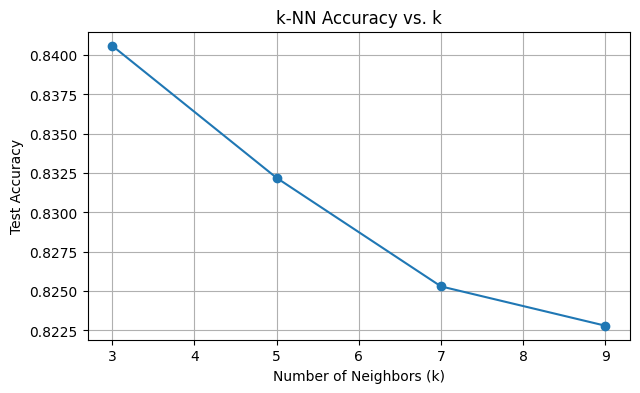

In [8]:
# Experimenting with multiple values of k
k_values = [3, 5, 7, 9]
accuracies = []

for k in k_values:
    model_k = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    model_k.fit(X_train_std, y_train)
    acc = model_k.score(X_test_std, y_test)
    accuracies.append(acc)
    print(f"k = {k} | Accuracy = {acc:.4f}")

# Plot k comparison
plt.figure(figsize=(7, 4))
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Test Accuracy")
plt.title("k-NN Accuracy vs. k")
plt.grid(True)
plt.show()

### Cross-Validation

In [9]:
from sklearn.model_selection import cross_val_score

# 5-fold Cross-Validation for Logistic Regression
cv_scores_lr = cross_val_score(logreg_ova, X_train_std, y_train, cv=5, scoring="accuracy")
print(f"Logistic Regression 5-Fold CV Accuracy: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")

# 5-fold Cross-Validation for k-NN (k=3)
knn_best = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
cv_scores_knn = cross_val_score(knn_best, X_train_std, y_train, cv=5, scoring="accuracy")
print(f"k-NN (k=3) 5-Fold CV Accuracy: {cv_scores_knn.mean():.4f} (+/- {cv_scores_knn.std():.4f})")

Logistic Regression 5-Fold CV Accuracy: 0.7263 (+/- 0.0043)
k-NN (k=3) 5-Fold CV Accuracy: 0.8234 (+/- 0.0024)


### Discussion

##### Model Comparison
k-NN clearly outperforms Logistic Regression with 82.34% CV accuracy versus 72.63%. This occurs because spatial and terrain features have complex non-linear boundaries that a linear model cannot fit well. Across both models, rare classes (like Class 4 and Class 5) remain the hardest to classify due to severe class imbalance.

##### Hyperparameter Tuning
For k-NN, smaller neighbor counts ($k=3$) achieve the highest accuracy ($84.06\%$ on the test set). Increasing $k$ gradually degrades performance ($82.28\%$ at $k=9$) because it over-smooths decision boundaries by including distant majority-class points.

##### Cross-Validation results
The 5-fold cross-validation confirms that the results are highly consistent and not due to an arbitrary train-test split:Logistic Regression: $72.63\% \pm 0.43\%$ accuracy.k-NN ($k=3$): $82.34\% \pm 0.24\%$ accuracy.